In [ ]:
https://cloud.mail.ru/public/mp8m/LL2xXnpxM

In [211]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
DATA = Path('../datasets')

import re
import requests
import pandas as pd
from io import BytesIO


def read_csv_from_mail_cloud(url, **read_csv_kwargs):
    """
    Загружает CSV-файл по публичной ссылке Mail Cloud
    и возвращает pandas.DataFrame.

    Parameters
    ----------
    url : str
        Публичная ссылка вида:
        https://cloud.mail.ru/public/...

    **read_csv_kwargs :
        Дополнительные параметры для pd.read_csv(),
        например sep=';', encoding='utf-8'.

    Returns
    -------
    pandas.DataFrame
    """

    # 1. Загружаем HTML публичной страницы
    page = requests.get(url)
    page.raise_for_status()

    # 2. Находим адрес download-сервера
    match = re.search(
        r'dispatcher.*?weblink_get.*?url"\s*:\s*"(.*?)"',
        page.text,
        flags=re.S
    )

    if match is None:
        raise RuntimeError(
            "Не удалось получить прямую ссылку на файл из Mail Cloud"
        )

    base_url = match.group(1)

    # 3. Берём идентификатор публичного файла
    public_id = url.split("/public/", 1)[1]

    download_url = f"{base_url}/{public_id}"

    # 4. Скачиваем сам файл
    response = requests.get(download_url)
    response.raise_for_status()

    # 5. Проверяем, что вместо файла не пришла HTML-страница
    content_type = response.headers.get("Content-Type", "")

    if "html" in content_type.lower():
        raise RuntimeError(
            "Mail Cloud вернул HTML-страницу вместо CSV-файла"
        )

    # 6. Читаем CSV
    return pd.read_csv(
        BytesIO(response.content),
        **read_csv_kwargs
    )

# СЕМИНАР 1 — Data Detective: от сырых данных к экономическому инсайту

**Множество решений до `model.fit()`, способных определить вывод**
  


1. Что является одной строкой / наблюдением?
2. Как сформирована выборка?
3. Что на самом деле означает переменная?
4. Как меняется вывод после агрегации, сегментации или преобразования?
5. Почему найденной закономерности пока нельзя доверять?

> **Prediction ≠ explanation ≠ causal inference.**


## 1. Доход домохозяйства и расходы на питание

**Вопрос:** как меняются расходы на питание по мере роста дохода домохозяйства?

Прежде чем что-либо рассчитывать, определите:

- что является одним наблюдением?
- какая переменная является целевой (результативной), а какая — объясняющей?
- из-за чего среднее значение может вводить в заблуждение?


In [212]:
engel = pd.read_csv(DATA / 'engel_food_expenditure_real.csv')
engel = read_csv_from_mail_cloud("https://cloud.mail.ru/public/Uiu7/vYGuSwtD9")

engel.head()

,income,foodexp
0,420.157651,255.839425
1,541.411707,310.958667
2,901.157457,485.680014
3,639.080229,402.997356
4,750.875606,495.560775


### 1.1 Разведочный анализ данных
Первый взгляд на данные

 - shape
 - dtypes 
 - missing values 
 - duplicated rows 
 и др

In [181]:
print('shape:', engel.shape)
print('\ndtypes:\n',engel.dtypes)
print('\nmissing values:\n', engel.isna().sum())
print('\nduplicates:', engel.duplicated().sum())
display(engel.describe(percentiles=[.01,.25,.5,.75,.95,.99]))

shape: (235, 2)

dtypes:
 income     float64
foodexp    float64
dtype: object

missing values:
 income     0
foodexp    0
dtype: int64

duplicates: 3


,income,foodexp
count,235.000000,235.000000
mean,982.473044,624.150111
std,519.230879,276.456997
min,377.058369,242.320202
1%,394.466465,251.200078
25%,638.875788,429.688763
50%,883.984917,582.541251
75%,1163.986672,743.881432
95%,1939.496564,1139.739758
99%,2533.343823,1549.783750


In [182]:
engel[engel.duplicated(subset=['income', 'foodexp'], keep=False)]

,income,foodexp
159,953.119224,621.117329
160,953.119224,621.117329
161,953.119224,621.117329
170,387.319526,242.320202
171,387.319526,242.320202


In [184]:
engel.loc[235] = [np.nan, np.nan]

new_rows = pd.DataFrame({
    "income": [np.nan, 1000000],
    "foodexp": [100, np.nan]
})

engel = pd.concat([engel, new_rows], ignore_index=True)
engel.tail()

,income,foodexp
233,743.077243,522.601906
234,1057.676711,750.320163
235,NaN,NaN
236,NaN,100.000000
237,1000000.000000,NaN


In [186]:
print('\nmissing values:\n', engel.isna().mean())


missing values:
 income     0.008403
foodexp    0.008403
dtype: float64


### 1.2 — data cleaning — не механическое удаление всего необычного.

Сравним среднее и медианное значение дохода.   
Построим график распределения доходов и график зависимости расходов на питание от дохода.


`Outlier` vs `Data error` vs `Influential observation`

Вопрос: является ли домохозяйство с самым высоким доходом очевидной ошибкой в данных или это может быть экономически осмысленное наблюдение? Стоит ли удалить это наблюдение? Какая доп информация может потребоватся?

mean income  : 982.4730439931191
median income: 883.984916757004


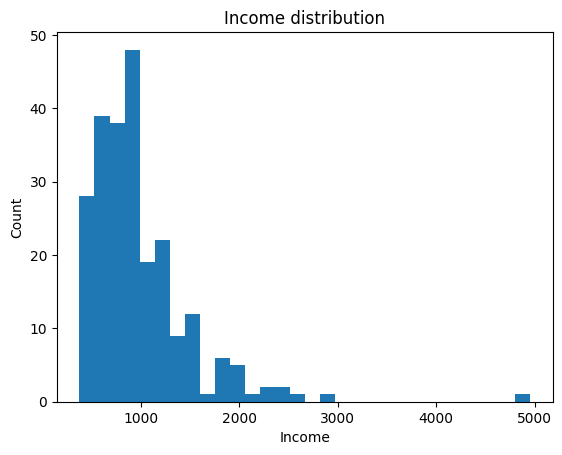

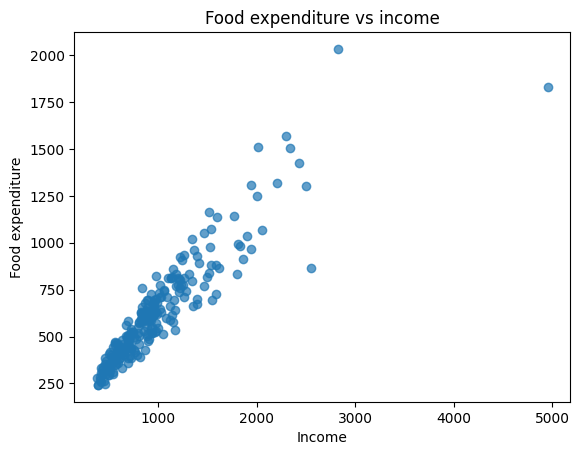

In [213]:
print('mean income  :', engel['income'].mean())
print('median income:', engel['income'].median())
fig, ax = plt.subplots()
ax.hist(engel['income'], bins=30)
ax.set_xlabel('Income'); ax.set_ylabel('Count'); ax.set_title('Income distribution')
plt.show()
fig, ax = plt.subplots()
ax.scatter(engel['income'], engel['foodexp'], alpha=.7)
ax.set_xlabel('Income'); ax.set_ylabel('Food expenditure'); ax.set_title('Food expenditure vs income')
plt.show()

### 1.3 Экономическая интерпретация

Закон Энгеля — эмпирическая закономерность в экономике потребления:
По мере роста дохода домохозяйства абсолютные расходы на питание обычно растут, но доля расходов на питание в доходе снижается.

Создадим переменную food_share = foodexp / income. 


In [227]:
engel2=engel.assign(food_share=engel['foodexp']/engel['income'], income_q=pd.qcut(engel['income'],4,labels=['Q1','Q2','Q3','Q4']))
engel2.head(5)


,income,foodexp,food_share,income_q
0,420.157651,255.839425,0.608913,Q1
1,541.411707,310.958667,0.574348,Q1
2,901.157457,485.680014,0.538951,Q3
3,639.080229,402.997356,0.630590,Q2
4,750.875606,495.560775,0.659977,Q2


In [228]:
engel2['income_q'].value_counts()

income_q
Q1    59
Q2    59
Q4    59
Q3    58
Name: count, dtype: int64

In [215]:
result=engel2.groupby('income_q', observed=False)\
    .agg(mean_income=('income','mean'), 
             mean_food=('foodexp','mean'), 
             mean_food_share=('food_share','mean'), 
             median_food_share=('food_share','median'))

display(round(result,2))

,mean_income,mean_food,mean_food_share,median_food_share
income_q,,,,
Q1,522.68,364.38,0.70,0.70
Q2,766.77,518.39,0.68,0.69
Q3,992.25,644.08,0.65,0.65
Q4,1648.36,970.08,0.60,0.62


---
## 2. Парадокс Симпсона. 

Cитуация, когда закономерность, наблюдаемая в агрегированных данных, существенно меняется или даже меняет направление после разделения данных на группы.

Перед нами агрегированные данные о поступлении в магистратуру University of California, Berkeley за 1973 год. 


- Admit: принят / не принят;
- Gender: мужчина / женщина;
- Dept: факультет/департамент A–F;
- Freq: количество заявителей в этой комбинации.


In [ ]:
berkeley = pd.read_csv(DATA / 'berkeley_admissions_1973_real.csv')
berkeley= read_csv_from_mail_cloud("https://cloud.mail.ru/public/BK4Z/RnKyzkmjP")

berkeley

,department,gender,admitted,rejected,applicants,admission_rate
0,A,Male,512,313,825,0.620606
1,A,Female,89,19,108,0.824074
2,B,Male,353,207,560,0.630357
3,B,Female,17,8,25,0.680000
4,C,Male,120,205,325,0.369231
5,C,Female,202,391,593,0.340641
6,D,Male,138,279,417,0.330935
7,D,Female,131,244,375,0.349333
8,E,Male,53,138,191,0.277487
9,E,Female,94,299,393,0.239186


### 2.1
Рассчитаем уровень поступления отдельно для мужчин и женщин. 

In [ ]:
overall=(berkeley.groupby('gender')[['admitted','applicants']].sum())
overall['admission_rate']=round(overall['admitted']/overall['applicants'], 2)
overall

,admitted,applicants,admission_rate
gender,,,
Female,557,1835,0.30
Male,1198,2691,0.45


### 2.2
Рассчитаем долю принятых абитуриентов отдельно по факультетам и полу.


In [162]:
pivot=berkeley.pivot(index='department',columns='gender',values='admission_rate')
display(round(pivot, 2))

apps=berkeley.pivot(index='department',columns='gender',values='applicants')
display(apps)


gender,Female,Male
department,,
A,0.82,0.62
B,0.68,0.63
C,0.34,0.37
D,0.35,0.33
E,0.24,0.28
F,0.07,0.06


gender,Female,Male
department,,
A,108,825
B,25,560
C,593,325
D,375,417
E,393,191
F,341,373


## Парадокс Симпсона. 

### Cитуация, когда закономерность, наблюдаемая в агрегированных данных, существенно меняется или даже меняет направление после разделения данных на группы.

---
## 3. Макроэкономические временные ряды

| Переменная | Смысл                                  |
| ---------- | -------------------------------------- |
| `date`     | конец квартала                         |
| `realgdp`  | реальный ВВП                           |
| `realcons` | реальное потребление                   |
| `realinv`  | реальные инвестиции                    |
| `realgovt` | реальные государственные расходы       |
| `realdpi`  | реальные располагаемые личные доходы   |
| `cpi`      | индекс потребительских цен, CPI        |
| `m1`       | денежный агрегат M1                    |
| `tbilrate` | ставка по краткосрочным Treasury Bills |
| `unemp`    | уровень безработицы, %                 |
| `pop`      | население                              |
| `infl`     | темп инфляции                          |
| `realint`  | реальная процентная ставка             |


In [ ]:
macro = pd.read_csv(DATA / 'us_macro_quarterly_real.csv', parse_dates=['date'])
macro = read_csv_from_mail_cloud("https://cloud.mail.ru/public/xyK7/Z9QJZr9gi")

macro.head()

,date,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959-03-31,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959-06-30,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959-09-30,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959-12-31,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960-03-31,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


### 3.1 Графики реального ВВП и реального потребления

Построим графики реального ВВП и реального потребления во времени. 

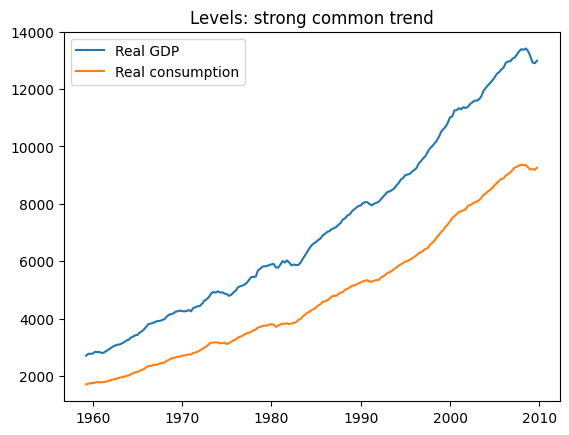

Correlation in levels: 0.9992291293603619


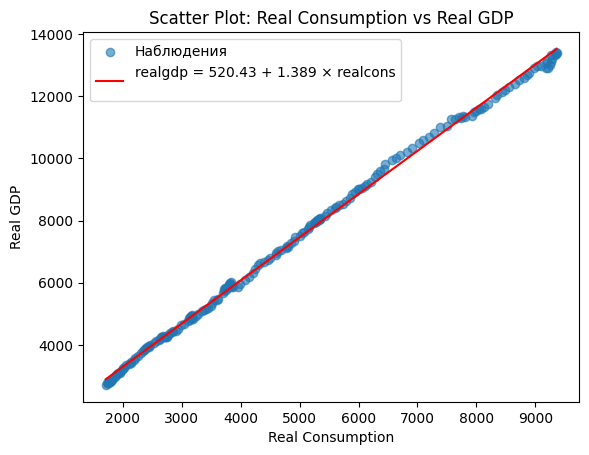

In [ ]:
fig, ax=plt.subplots()
ax.plot(macro['date'], macro['realgdp'], label='Real GDP')
ax.plot(macro['date'], macro['realcons'], label='Real consumption')
ax.legend(); 
ax.set_title('Levels: strong common trend');
plt.show()
print('Correlation in levels:', macro[['realgdp','realcons']].corr().iloc[0,1])


fig, ax=plt.subplots()

y = macro['realgdp'].to_numpy()
x = macro['realcons'].to_numpy()

# Модель: realcons = a + b * realgdp
b, a = np.polyfit(x, y, deg=1)
y_pred = a + b * x
x_line = np.linspace(x.min(), x.max(), 200)

ax.scatter(x, y, alpha=0.6, label='Наблюдения')
ax.plot(
    x_line, a + b * x_line,
    color='red',
    label=f'realgdp = {a:.2f} + {b:.3f} × realcons\n',
)


ax.set_xlabel('Real Consumption')
ax.set_ylabel('Real GDP')
ax.set_title('Scatter Plot: Real Consumption vs Real GDP')
plt.legend()
plt.show()


### 3.2 Преобразуем данные

Рассчитаем квартальные логарифмические темпы роста реального ВВП и потребления: $100\Delta\log X_t$. 
Сравним корреляции для уровней и для темпов роста.

Почему две временные серии с выраженным трендом могут выглядеть сильно связанными, даже если их краткосрочное совместное движение намного слабее?

corr(levels)= 0.9992291293603619
corr(growth)= 0.6575578800541723


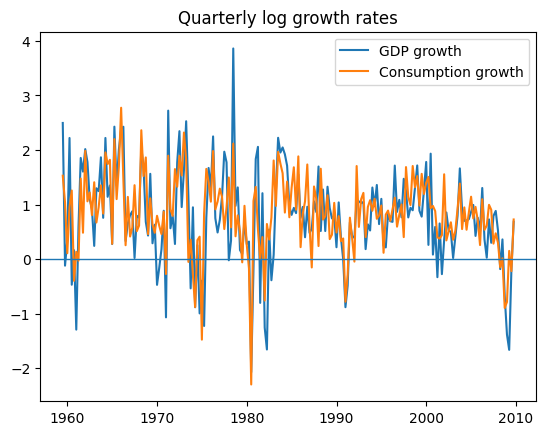

In [ ]:
m=macro.copy()
m['gdp_growth']=100*np.log(m['realgdp']).diff()
m['cons_growth']=100*np.log(m['realcons']).diff()


print('corr(levels)=',m[['realgdp','realcons']].corr().iloc[0,1])
print('corr(growth)=',m[['gdp_growth','cons_growth']].corr().iloc[0,1])


fig, ax=plt.subplots()
ax.plot(m['date'],m['gdp_growth'],label='GDP growth')
ax.plot(m['date'],m['cons_growth'],label='Consumption growth')
ax.axhline(0,linewidth=1); ax.legend(); ax.set_title('Quarterly log growth rates'); plt.show()

## Какой коэффициент корреляции "правильный"?  0.9992 vs 0.6575?

---
## 4. Качество данных 

Перед вами синтетический датасет клиентских транзакций


| Поле                                   | Смысл                                                                                   |
| -------------------------------------- | --------------------------------------------------------------------------------------- |
| `client_id`                            | идентификатор клиента                                                                   |
| `date`                                 | дата транзакции                                                                         |
| `amount`                               | сумма транзакции                                                                        |
| `segment`                              | тип/сегмент клиента, например `regular`, `opportunistic`                                |
| `channel`                              | канал совершения операции, например `app`, `manager`                                    |
| `country`                              | страна клиента, например `RU`, `BY`, `AM`                                               |
| `declared_income`                      | заявленный доход клиента                                                                |
| `days_until_last_observed_transaction` | число дней от текущей транзакции до последней транзакции этого клиента во всём датасете |


In [208]:
tx = pd.read_csv(DATA / 'client_transactions_pedagogical_synthetic.csv', parse_dates=['date'])
tx = read_csv_from_mail_cloud("https://cloud.mail.ru/public/2pQM/R12SB4KA5")
tx.head()

,client_id,date,amount,segment,channel,country,declared_income,days_until_last_observed_transaction
0,C0389,2025-01-01,10222.122871,regular,app,RU,66611.282516,178
1,C0139,2025-06-09,35507.294916,opportunistic,manager,BY,143214.926819,12
2,C0107,2025-06-09,43346.870575,regular,app,RU,56532.060379,20
3,C0205,2025-05-09,3254.168746,regular,app,AM,33782.362580,48
4,C0247,2025-06-07,26433.186691,opportunistic,manager,RU,NaN,0


In [169]:

display(tx['segment'].value_counts())
display(tx['channel'].value_counts())
display(tx['country'].value_counts())

segment
regular          5977
opportunistic    1162
new               208
Name: count, dtype: int64

channel
app        4329
web        1814
manager    1204
Name: count, dtype: int64

country
RU    5568
BY     656
KZ     575
AM     548
Name: count, dtype: int64

In [118]:
print('shape:',tx.shape)
print('duplicates:',tx.duplicated().sum())
print('missing share:\n',tx.isna().mean().sort_values(ascending=False))
print('amount summary:\n',tx['amount'].describe(percentiles=[.01,.5,.95,.99]))
print('negative amounts:',(tx['amount']<0).sum())
print('date range:',tx['date'].min(),tx['date'].max())
print('clients:',tx['client_id'].nunique())

shape: (7347, 8)
duplicates: 35
missing share:
 declared_income                         0.093371
client_id                               0.000000
date                                    0.000000
amount                                  0.000000
segment                                 0.000000
channel                                 0.000000
country                                 0.000000
days_until_last_observed_transaction    0.000000
dtype: float64
amount summary:
 count    7.347000e+03
mean     2.671082e+04
std      9.304973e+04
min     -6.127728e+04
1%       1.640105e+03
50%      1.162571e+04
95%      7.192614e+04
99%      2.797302e+05
max      2.642063e+06
Name: amount, dtype: float64
negative amounts: 30
date range: 2025-01-01 00:00:00 2025-06-29 00:00:00
clients: 400


### 4.2 Пропущенный доход

Создадим индикатор пропущенных значений для declared_income. Сравните долю пропусков между различными segment и channel.

Что будет потеряно, если просто удалить все строки, в которых значение дохода отсутствует?

In [119]:
tx2=tx.assign(income_missing=tx['declared_income'].isna())
display(pd.crosstab(tx2['segment'],tx2['income_missing'],normalize='index'))
display(pd.crosstab(tx2['channel'],tx2['income_missing'],normalize='index'))
print('Удаление строк с пропущенным доходом изменяет состав выборки')

income_missing,False,True
segment,,
new,0.817308,0.182692
opportunistic,0.706540,0.293460
regular,0.948636,0.051364


income_missing,False,True
channel,,
app,0.932086,0.067914
manager,0.814784,0.185216
web,0.906836,0.093164


Удаление строк с пропущенным доходом изменяет состав выборки


### 4.3  Единица наблюдения

Создадим признаки по клиентам: 
- количество транзакций, 
- сумму операций, 
- сумму положительных операций, 
- средний размер транзакции, 
- количество активных дней,
- дату первой и последней транзакции.

Как меняется исследовательский вопрос, когда единица наблюдения меняется с транзакции на клиента?

In [ ]:
client=(tx.groupby('client_id')
        .agg(n_rows=('amount','size'), 
             net_amount=('amount','sum'), 
             avg_amount=('amount','mean'),
             active_days=('date','nunique'), 
             first_date=('date','min'), 
             last_date=('date','max')))
pos=tx.assign(pos_amount=tx['amount'].clip(lower=0)).groupby('client_id')['pos_amount'].sum()
client['positive_gross_amount']=pos

display(client.head())
display(client.describe())

,n_rows,net_amount,avg_amount,active_days,first_date,last_date,positive_gross_amount
client_id,,,,,,,
C0001,7,396891.826470,56698.832353,7,2025-01-01,2025-05-30,396891.826470
C0002,25,274116.940646,10964.677626,25,2025-01-06,2025-06-18,275782.110324
C0003,7,45766.999472,6538.142782,7,2025-01-22,2025-06-26,45766.999472
C0004,4,131292.258405,32823.064601,4,2025-04-26,2025-06-26,131292.258405
C0005,38,432822.416758,11390.063599,38,2025-01-01,2025-06-28,432822.416758


,n_rows,net_amount,avg_amount,active_days,first_date,last_date,positive_gross_amount
count,400.000000,4.000000e+02,400.000000,400.000000,400,400,4.000000e+02
mean,18.367500,4.906110e+05,35978.029169,18.280000,2025-01-16 14:05:59.999999744,2025-06-13 23:24:00,4.917797e+05
min,1.000000,-1.951366e+03,-975.683151,1.000000,2025-01-01 00:00:00,2025-02-21 00:00:00,2.310460e+03
25%,7.750000,2.600854e+05,11998.765453,7.000000,2025-01-03 00:00:00,2025-06-11 00:00:00,2.614960e+05
50%,19.000000,3.813249e+05,17039.439070,19.000000,2025-01-07 00:00:00,2025-06-22 00:00:00,3.816202e+05
75%,28.000000,5.653217e+05,43334.295452,28.000000,2025-01-21 00:00:00,2025-06-27 00:00:00,5.653217e+05
max,41.000000,3.949043e+06,438782.608029,39.000000,2025-06-09 00:00:00,2025-06-29 00:00:00,3.949043e+06
std,11.368842,4.742119e+05,50269.952577,11.297818,NaN,NaN,4.744753e+05


### 4.4 Поиск утечки данных

Изучите признак `days_until_last_observed_transaction`. Можно ли использовать его для прогнозирования того, совершит ли клиент ещё одну транзакцию в следующем месяце, если прогноз строится для исторических дат? 



In [173]:
display(tx[['client_id','date','days_until_last_observed_transaction']].sort_values(['client_id','date']).head(12))


,client_id,date,days_until_last_observed_transaction
5644,C0001,2025-01-01,149
3323,C0001,2025-01-12,138
6041,C0001,2025-03-06,85
2738,C0001,2025-04-09,51
1462,C0001,2025-04-22,38
1593,C0001,2025-04-30,30
3590,C0001,2025-05-30,0
3893,C0002,2025-01-06,163
5330,C0002,2025-01-09,160
4038,C0002,2025-01-17,152


## 4.5 Финальная задача
 
Вы получили этот датасет от бизнеса и должны через неделю показать первую модель прогнозирования активности клиента.

Какие пять вопросов вы зададите владельцу данных, на которые вы хотите получить ответ прежде, чем начнёте моделирование.